<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/rna-seq/07_normalizasyon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Normalizasyon: herkese aynı cetvel

Geçen rehber bir soruyla bitmişti: WT_3'ün toplamı WT_1'in kaç katı? İlk hücre borcu ödüyor. Bu defterde o farkın yarattığı yanılsamayı görecek, "milyon başına" düşünmenin neyi çözüp neyi çözemediğini bir deneyle test edecek ve DESeq2'nin cetvelini kendi elinizle kuracaksınız.

In [1]:
import pandas as pd
import numpy as np

t = pd.read_csv('https://raw.githubusercontent.com/melissa-04/melisayla-biyoinformatik/main/data/rna-seq/sayim_tablosu.csv')
ornekler = ['WT_1', 'WT_2', 'WT_3', 'KO_1', 'KO_2', 'KO_3']
g = t.set_index('gen_id')[ornekler]

kutuphane = g.sum()
print((kutuphane / 1e6).round(2), ' (milyon okuma)')
print('WT_3 / WT_1 =', round(kutuphane['WT_3'] / kutuphane['WT_1'], 2))

WT_1    13.60
WT_2    11.93
WT_3    32.36
KO_1    12.26
KO_2    18.34
KO_3    13.86
dtype: float64  (milyon okuma)
WT_3 / WT_1 = 2.38


## 1. Yanılsama

Gapdh, hücrenin temel enerji metabolizmasında çalışan, "hep açık" diye bilinen bir gen. Üç WT örneği aynı genotipin kopyaları; biyolojik olarak Gapdh'den aşağı yukarı aynı şeyi beklersiniz. Ham sayılara bakın ve WT_3'e dikkat edin: gen mi coştu, makine mi?

Küçük bir alışkanlık: altıncı rehberin uyarısına sadık kalıp aramayı hep `gen_id` üzerinden yapıyoruz; `gen()` yardımcısı adı alır, kimliğe çevirir, satırı getirir.

In [2]:
def gen(ad, tablo):
    kimlik = t.loc[t.gen_adi == ad, 'gen_id'].iloc[0]
    return tablo.loc[kimlik]

print(gen('Gapdh', g))
print('WT içi: WT_3 / WT_1 =', round(gen('Gapdh', g)['WT_3'] / gen('Gapdh', g)['WT_1'], 2))

WT_1    14363
WT_2    14431
WT_3    32744
KO_1    22290
KO_2    35900
KO_3    29930
Name: ENSMUSG00000057666.19, dtype: int64
WT içi: WT_3 / WT_1 = 2.28


## 2. Milyon başına: CPM

En basit düzeltme, her sayımı kendi kütüphanesine bölüp milyonla çarpmak: CPM (counts per million). Anlamı şu: "bu gen, o örnekteki her bir milyon okumadan kaçını aldı?" Derinlik paydaya girince yanılsama kaybolmalı; WT sütunlarına bakın.

(KO sütunlarında Gapdh'nin başka bir hikâyesi var gibi görünecek; şimdilik takılmayın, "bu fark gerçek mi" sorusu tam olarak sekizinci rehberin konusu.)

In [3]:
cpm = g.div(kutuphane, axis=1) * 1e6
print(gen('Gapdh', cpm).round(0))

WT_1    1056.0
WT_2    1210.0
WT_3    1012.0
KO_1    1817.0
KO_2    1958.0
KO_3    2159.0
Name: ENSMUSG00000057666.19, dtype: float64


## 3. Milyon bir pastadır

CPM'in gizli varsayımı: milyon, herkese adil dağıtılan bir bütçedir. Ama milyon sabit bir pastadır; bir gen delirip pastadan dev bir dilim alırsa, sayımı hiç değişmeyen bütün öteki genlerin dilimi küçülür.

Deneyle görelim: WT_1'in kopyasını alıp **sadece Afp'yi 50 katına çıkaran** sahte bir örnek yaratıyoruz. Gapdh, Actb ve Slc4a1'in sayımlarına dokunmuyoruz bile. CPM'lerine ne oluyor?

In [4]:
sahte = g['WT_1'].copy()
sahte[gen('Afp', g).name] = gen('Afp', g)['WT_1'] * 50

cpm_once  = g['WT_1'] / g['WT_1'].sum() * 1e6
cpm_sonra = sahte / sahte.sum() * 1e6

print('Sahte kütüphane büyümesi: %', round(100 * (sahte.sum() / g['WT_1'].sum() - 1), 1))
for ad in ['Gapdh', 'Actb', 'Slc4a1']:
    o, s = gen(ad, cpm_once), gen(ad, cpm_sonra)
    print(f'{ad}: sayımı aynı, CPM {o:.0f} -> {s:.0f}  (%{100 * (s / o - 1):.0f})')

Sahte kütüphane büyümesi: % 26.3
Gapdh: sayımı aynı, CPM 1056 -> 836  (%-21)
Actb: sayımı aynı, CPM 1933 -> 1530  (%-21)
Slc4a1: sayımı aynı, CPM 5997 -> 4748  (%-21)


## 4. DESeq2'nin cetveli: oranların medyanı

Üç suçsuz genin hepsi aynı oranda düştü; suç genlerde değil, pastada. Bunu çözen tarif, DESeq2'nin *median-of-ratios* yöntemi:

1. Her gen için bütün örneklerin geometrik ortalamasını al; bu, "referans örnek".
2. Her örnekte, her genin sayımını referansa oranla.
3. O örneğin *size factor*'ı = bu oranların **medyanı**.

Medyanın sihri şurada: Afp gibi bir dev delirse bile sıralamada sadece bir gendir; ortadaki sıradan gen konuşur, cetveli tipik gen kurar. Bir teknik not: geometrik ortalama sıfır görünce çöker, bu yüzden referansa yalnız her örnekte sıfırdan büyük olan genler girer.

In [5]:
poz = g[(g > 0).all(axis=1)]
print('Referansa giren gen:', len(poz))

logg = np.log(poz)
referans = logg.mean(axis=1)                            # her genin log-geometrik ortalaması
sf = np.exp(logg.sub(referans, axis=0).median(axis=0))  # örnek başına oranların medyanı

kut_f = kutuphane / np.exp(np.log(kutuphane).mean())
print('\nSize factor (medyan-oran):'); print(sf.round(2))
print('\nKütüphane faktörü:'); print(kut_f.round(2))
print('\nSapma (%):'); print(((sf / kut_f - 1) * 100).round(1))

Referansa giren gen: 18470

Size factor (medyan-oran):
WT_1    0.76
WT_2    0.63
WT_3    1.98
KO_1    0.88
KO_2    1.28
KO_3    0.96
dtype: float64

Kütüphane faktörü:
WT_1    0.85
WT_2    0.75
WT_3    2.03
KO_1    0.77
KO_2    1.15
KO_3    0.87
dtype: float64

Sapma (%):
WT_1   -10.5
WT_2   -15.2
WT_3    -2.4
KO_1    14.2
KO_2    11.0
KO_3    10.9
dtype: float64


## 5. Normalizasyondan sonra

Sapma satırını okuyun: iki faktör aynı olsaydı bu rehberin yarısı gereksizdi. Değiller — ve sapmanın yönüne bakın: WT'lerde hep bir yöne, KO'larda hep öbür yöne. İki grup, milyonlarını farklı genlere harcıyor; kütüphane büyüklüğü bunu göremez, oranların medyanı görür.

Normalize sayım = ham sayım / size factor. Dikkat: bu işlem toplamları eşitlemez ve eşitlemek zorunda da değildir; medyan-oran, *tipik geni* hizaya getirir. Grafikte kalan WT-KO farkı bir hata değil, kompozisyon farkının imzasıdır.

WT_1    18788.0
WT_2    22746.0
WT_3    16517.0
KO_1    25348.0
KO_2    28110.0
KO_3    31025.0
Name: ENSMUSG00000057666.19, dtype: float64


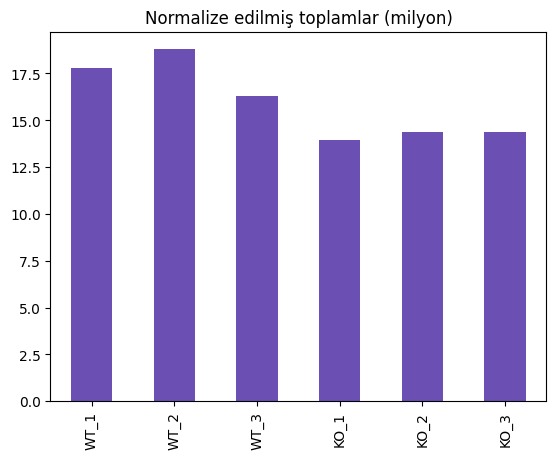

In [6]:
norm = g.div(sf, axis=1)
print(gen('Gapdh', norm).round(0))
(norm.sum() / 1e6).plot(kind='bar', color='#6B4FB3', title='Normalize edilmiş toplamlar (milyon)');

## Kendin dene

Üç görev. Birincisi: yukarıdaki hücreden altı size factor'ı not edin; sayılarınız benimkiyle aynı çıkmalı, çünkü tablo da tarif de aynı. İkincisi: bu defterde gördüklerinizle şu cümleyi tamamlayın: **"Kütüphane büyüklüğüne bölmek yetmez, çünkü..."** Üçüncüsü bir av: normalize tabloda WT ortalaması 1000'in üzerinde olup KO/WT oranı en küçük olan geni bulun (`norm`'dan WT ve KO ortalamalarını alın, filtreleyin, oranı sıralayın). Bulduğunuz adı bir kenara yazın ve kimseye söylemeyin; sekizinci rehber baştan sona onun duruşması olacak.